# 01 — Data assembly and exploratory analysis

This notebook establishes what is in the Ames housing data before any model is built. It uses
Dean De Cock's full release of 2,930 sales from 2006 to July 2010, with `SalePrice` for every row,
in place of the pre-split copy the project's first pass used. That copy turns out to be a
truncated, partly corrupted view of the source, and four of the modelling decisions made
downstream in the first pass were already contradicted by the evidence here. §3 covers the
clearest case: five columns deleted for being mostly empty, where an empty value meant the home
lacked the feature (no pool, no fence) rather than that the value was unknown.

Terms are defined in [the glossary](../docs/GLOSSARY.md).

The first pass worked from 2,051 training rows with a target and 878 test rows without one. With
no labels on the holdout, the only feedback was an externally computed score, so a silent
corruption of the test frame (Model Risk Log defect #1) could not be detected from inside the
notebook.

De Cock's publication carries all 2,930 rows *with* `SalePrice`. Recovering those 878 labels makes
proper holdout scoring possible, and in notebook 03 it allows the first-pass predictions to be
re-scored so the cost of the defects can be measured.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import ARMS_LENGTH_CONDITION, FIGURES, RAW
from ames.data import load_properties
from ames.features import ABSENT_NOMINAL, ABSENT_ORDINAL, prepare
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "01 · Data & EDA"
SOURCE = "Source: De Cock (2011), Ames City Assessor records · 2,930 sales, 2006–2010."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

props = load_properties()
print(f"{len(props):,} properties x {props.shape[1]} columns")

2,930 properties x 89 columns


## 1. What the widened dataset adds

Three things the pre-split CSVs could not provide: the withheld labels, property
coordinates, and a contiguous 2006–2010 time axis with enough rows per year to split on.

In [2]:
summary = pd.DataFrame({
    "rows": [2051, 878, len(props)],
    "has SalePrice": ["yes", "no (withheld)", "yes"],
    "has lat/long": ["no", "no", f"{props['Latitude'].notna().mean():.1%}"],
}, index=["BASELINE train.csv", "BASELINE test.csv", "De Cock full extract"])
summary

,rows,has SalePrice,has lat/long
BASELINE train.csv,2051,yes,no
BASELINE test.csv,878,no (withheld),no
De Cock full extract,2930,yes,99.6%


In [3]:
by_year = props.groupby("Yr Sold").agg(
    sales=("SalePrice", "size"),
    median_price=("SalePrice", "median"),
    arms_length=("Sale Condition", lambda s: (s == ARMS_LENGTH_CONDITION).mean()),
)
by_year["median_price"] = by_year["median_price"].round(0)
by_year["arms_length"] = by_year["arms_length"].round(3)
by_year

,sales,median_price,arms_length
Yr Sold,,,
2006,625,159500.0,0.741
2007,694,165125.0,0.800
2008,622,161000.0,0.857
2009,648,160850.0,0.866
2010,341,155000.0,0.883


2010 is a partial year (the extract stops in July), which is why its count is roughly
half the others. That matters for the temporal split: the test period is 2009 plus
seven months of 2010, not two full years.

In [4]:
print(props.loc[props["Yr Sold"] == 2010, "Mo Sold"].agg(["min", "max"]).to_dict())
print(f"last sale in the data: {props['sale_date'].max():%B %Y}")

{'min': 1, 'max': 7}
last sale in the data: July 2010


## 2. The target: why `log(SalePrice)`

The first-pass EDA reached the right conclusion here and then did not act on it: those
models were fit on raw `SalePrice` (Model Risk Log defect #5). House prices are skewed, with a
long tail of expensive homes that pulls the average above the middle. Working with the logarithm
of price treats errors proportionally: a $20k error on a $100k home and a $100k error on a $500k
home are the same proportional mistake, and logs put them on the same footing. The evidence below
shows how strongly the data favours the log target, and what fitting on raw dollars does to the
residuals.

In [5]:
price = props["SalePrice"]
log_price = np.log(price)

normality = pd.DataFrame({
    "skew": [stats.skew(price), stats.skew(log_price)],
    "excess kurtosis": [stats.kurtosis(price), stats.kurtosis(log_price)],
    "Shapiro-Wilk W": [stats.shapiro(price.sample(2000, random_state=0)).statistic,
                       stats.shapiro(log_price.sample(2000, random_state=0)).statistic],
}, index=["SalePrice", "log(SalePrice)"]).round(4)
normality

,skew,excess kurtosis,Shapiro-Wilk W
SalePrice,1.7426,5.1081,0.8702
log(SalePrice),-0.0148,1.5093,0.9866


  saved reports/figures/01_target_distribution.png


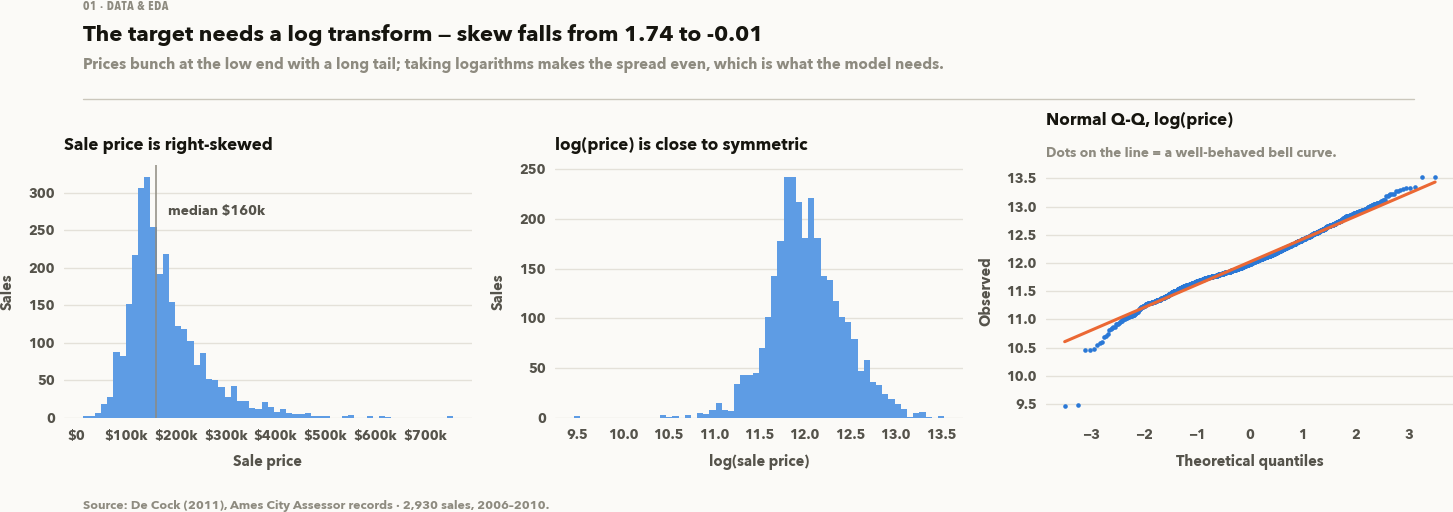

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2))

axes[0].hist(price, bins=60, color=SUBJECT_FILL, edgecolor=None)
axes[0].set_title("Sale price is right-skewed")
axes[0].set_xlabel("Sale price")
axes[0].xaxis.set_major_formatter(money)
axes[0].set_ylabel("Sales")
annotate(axes[0], price.median(), axes[0].get_ylim()[1] * 0.82,
         f"median {money(price.median())}", offset=(8, 0))
axes[0].axvline(price.median(), color=INK_MUTED, lw=1)

axes[1].hist(log_price, bins=60, color=SUBJECT_FILL)
axes[1].set_title("log(price) is close to symmetric")
axes[1].set_xlabel("log(sale price)")
axes[1].set_ylabel("Sales")

# .to_numpy(): scipy 1.14 routes a Series through a deprecated swapaxes path.
stats.probplot(log_price.to_numpy(), dist="norm", plot=axes[2])
axes[2].get_lines()[0].set(color=BLUE, marker="o", markersize=2, linestyle="none")
axes[2].get_lines()[1].set(color=ORANGE, linewidth=2)
titled(axes[2], "Normal Q-Q, log(price)",
       "Dots on the line = a well-behaved bell curve.")
axes[2].set_xlabel("Theoretical quantiles")
axes[2].set_ylabel("Observed")

finish(fig, "The target needs a log transform — skew falls from "
                f"{stats.skew(price):.2f} to {stats.skew(log_price):.2f}",
           "Prices bunch at the low end with a long tail; taking logarithms makes the "
           "spread even, which is what the model needs.")
save(fig, "01_target_distribution")
plt.show()

### The cost of ignoring it

Fitting on raw dollars makes the loss function care about expensive houses far more than
cheap ones, because squared error scales with the square of the price level. The
residuals then fan out with the fitted value, the artefact the first pass saved as
`Graph/Homoscedacity.png` and left uncorrected. This pattern, errors growing with the
size of the prediction, is called heteroskedasticity.

The test below is Levene's, comparing residual variance across quartiles of the fitted
value. On raw dollars it rejects equal variance overwhelmingly; on the log target the
statistic falls by orders of magnitude.

In [7]:
from sklearn.linear_model import LinearRegression

numeric_only = props.select_dtypes("number").drop(columns=["SalePrice", "Order", "PID"])
X_demo = numeric_only.fillna(numeric_only.median())

rows = []
for target_series, name in [(price, "raw SalePrice"), (log_price, "log(SalePrice)")]:
    fitted = LinearRegression().fit(X_demo, target_series).predict(X_demo)
    resid = (target_series - fitted).to_numpy()
    quartiles = np.array_split(resid[np.argsort(fitted)], 4)
    rows.append({
        "fitted on": name,
        "Levene statistic": stats.levene(*quartiles).statistic,
        "p-value": stats.levene(*quartiles).pvalue,
        "residual sd, cheapest quartile": quartiles[0].std(),
        "residual sd, dearest quartile": quartiles[-1].std(),
    })
pd.DataFrame(rows).set_index("fitted on")

,Levene statistic,p-value,"residual sd, cheapest quartile","residual sd, dearest quartile"
fitted on,,,,
raw SalePrice,103.735374,8.093229e-64,18993.246205,51768.445135
log(SalePrice),20.197582,5.924346e-13,0.178274,0.160835


## 3. Missingness: `NA` means *absent*, not *unknown*

The first-pass cleaning notebook dropped `Pool QC`, `Misc Feature`, `Alley`, `Fence` and
`Fireplace Qu` because they were 76–99% null (Model Risk Log defect #9). De Cock's
data dictionary states that `NA` in these columns codes "No Pool", "None",
"No Alley Access", "No Fence" and "No Fireplace".

Below, each of the five is split into "feature absent" versus "feature present, graded",
and the two groups are priced.

In [8]:
rows = []
for col in ["Pool QC", "Misc Feature", "Alley", "Fence", "Fireplace Qu"]:
    absent, present = props[col].isna(), props[col].notna()
    rows.append({
        "column": col,
        "null %": props[col].isna().mean(),
        "meaning of NA": {"Pool QC": "No Pool", "Misc Feature": "None",
                          "Alley": "No Alley Access", "Fence": "No Fence",
                          "Fireplace Qu": "No Fireplace"}[col],
        "median price, absent": props.loc[absent, "SalePrice"].median(),
        "median price, present": props.loc[present, "SalePrice"].median(),
        "n present": int(present.sum()),
    })
informative = pd.DataFrame(rows)
informative["price lift"] = (informative["median price, present"]
                             / informative["median price, absent"] - 1)
informative.round(3)

,column,null %,meaning of NA,"median price, absent","median price, present",n present,price lift
0,Pool QC,0.996,No Pool,160000.0,235000.0,13,0.469
1,Misc Feature,0.964,None,161250.0,150750.0,106,-0.065
2,Alley,0.932,No Alley Access,163000.0,143550.0,198,-0.119
3,Fence,0.805,No Fence,171250.0,140000.0,572,-0.182
4,Fireplace Qu,0.485,No Fireplace,135500.0,194000.0,1508,0.432


  saved reports/figures/01_informative_nulls.png


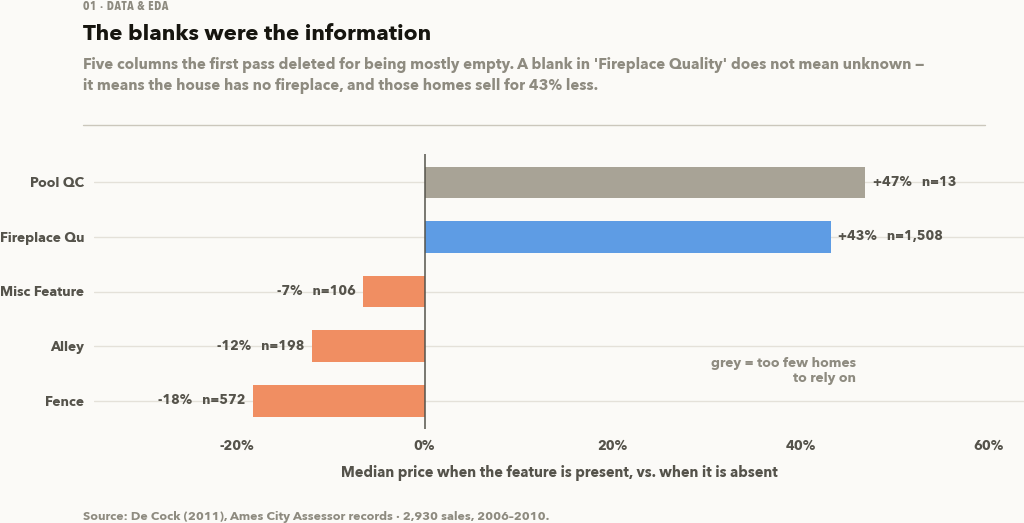

In [9]:
fig, ax = plt.subplots(figsize=(9.6, 5.3))
order = informative.sort_values("price lift")
y = np.arange(len(order))
# Pool QC is a real effect on 13 houses.  Drawn in grey so it cannot be read as
# comparable evidence to Fireplace Qu, which rests on 1,508.
colors = [CONTEXT_DARK if n < 50 else (CONTRAST_FILL if v < 0 else SUBJECT_FILL)
          for v, n in zip(order["price lift"], order["n present"])]
bars = ax.barh(y, order["price lift"], color=colors, height=0.58)
ax.set_yticks(y, order["column"])
ax.axvline(0, color=INK_SECONDARY, lw=1)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Median price when the feature is present, vs. when it is absent")
bar_labels(ax, bars,
           [f"{v:+.0%}   n={n:,}" for v, n in zip(order["price lift"], order["n present"])])
ax.margins(x=0.26)
annotate(ax, order["price lift"].max(), 0.55, "grey = too few homes\nto rely on",
         color=INK_MUTED, offset=(-6, 0), ha="right")
finish(fig, "The blanks were the information",
       "Five columns the first pass deleted for being mostly empty. A blank in "
       "'Fireplace Quality' does not mean unknown — it means the house has no fireplace, "
       "and those homes sell for 43% less.")
save(fig, "01_informative_nulls")
plt.show()

`Fireplace Qu` is the clearest case: 1,508 homes, over half the dataset, have a
fireplace and a graded quality, and they sell for **43% more** than homes without one.
Dropping the column discarded a fully observed feature on 51% of the data.
(`Pool QC` shows the largest lift, +47%, but on 13 homes: a real effect that no model
can estimate reliably. It is kept as a binary "has pool" signal rather than a quality ladder.)

The *sign* also differs across these five. A fence is associated with
lower prices in Ames, because it proxies for smaller lots in denser blocks rather than
acting as an amenity. An encoder that treated all five as "missing, impute the mode" would erase
that distinction. `ames.features` encodes them as ordinal ladders with `0 = absent`.

In [10]:
print(f"columns encoded with an explicit 'absent' level: "
      f"{len(ABSENT_ORDINAL)} ordinal, {len(ABSENT_NOMINAL)} nominal")
genuinely_missing = (props[["Lot Frontage", "Garage Yr Blt"]].isna().mean()
                     .rename("share missing").to_frame().round(3))
genuinely_missing["treatment"] = "median imputation, fit on training rows only"
genuinely_missing

columns encoded with an explicit 'absent' level: 11 ordinal, 4 nominal


,share missing,treatment
Lot Frontage,0.167,"median imputation, fit on training rows only"
Garage Yr Blt,0.054,"median imputation, fit on training rows only"


## 4. Known data errors that were left in place

Two corrections were written in the first-pass cleaning notebook and then commented out
(Model Risk Log defect #8), so neither ever ran.

In [11]:
raw_txt = pd.read_csv(RAW / "AmesHousing.txt", sep="\t")
typo = raw_txt.loc[raw_txt["Garage Yr Blt"] == 2207,
                   ["PID", "Year Built", "Yr Sold", "Garage Yr Blt"]]
print("As shipped by De Cock — a garage built in 2207:")
print(typo.to_string(index=False))
print(f"\nAfter ames.data.clean_known_errors: "
      f"max Garage Yr Blt = {props['Garage Yr Blt'].max():.0f}")

As shipped by De Cock — a garage built in 2207:
      PID  Year Built  Yr Sold  Garage Yr Blt
916384070        2006     2007         2207.0

After ames.data.clean_known_errors: max Garage Yr Blt = 2010


      PID  Gr Liv Area  SalePrice Sale Condition  Overall Qual Neighborhood
908154235         5642     160000        Partial            10      Edwards
528320050         4476     745000        Abnorml            10      NoRidge
528351010         4316     755000         Normal            10      NoRidge
908154195         5095     183850        Partial            10      Edwards
908154205         4676     184750        Partial            10      Edwards
  saved reports/figures/01_outliers.png


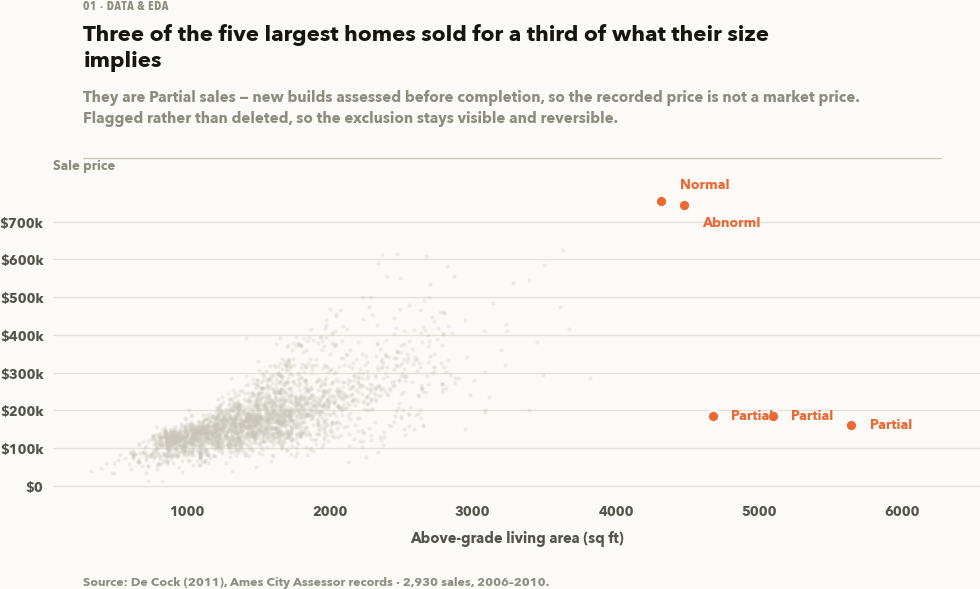

In [12]:
outliers = props.loc[props["is_outlier_grlivarea"],
                     ["PID", "Gr Liv Area", "SalePrice", "Sale Condition",
                      "Overall Qual", "Neighborhood"]]
print(outliers.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.2, 5.9))
normal = props[~props["is_outlier_grlivarea"]]
ax.scatter(normal["Gr Liv Area"], normal["SalePrice"], s=7, alpha=0.28,
           color=CONTEXT, linewidths=0)
ax.scatter(outliers["Gr Liv Area"], outliers["SalePrice"], s=62, color=CONTRAST,
           edgecolor=SURFACE, linewidths=1.8, zorder=5)
# Stagger the labels: two of the five sit almost on top of each other.
OFFSETS = {0: (12, 10), 1: (12, -12), 2: (12, 0), 3: (12, 0), 4: (12, 0)}
for i, (_, r) in enumerate(outliers.sort_values("SalePrice", ascending=False).iterrows()):
    annotate(ax, r["Gr Liv Area"], r["SalePrice"], r["Sale Condition"],
             color=CONTRAST, offset=OFFSETS.get(i, (12, 0)), fontweight="demibold")
ax.set_xlim(right=outliers["Gr Liv Area"].max() * 1.16)
ax.set_xlabel("Above-grade living area (sq ft)")
ax.yaxis.set_major_formatter(money)
axis_note(ax, "Sale price")
finish(fig, "Three of the five largest homes sold for a third of what their size implies",
       "They are Partial sales — new builds assessed before completion, so the recorded "
       "price is not a market price. Flagged rather than deleted, so the exclusion stays "
       "visible and reversible.")
save(fig, "01_outliers")
plt.show()

De Cock's own paper recommends removing these five. Three are `Partial` sales (homes
not finished when assessed), so they are not market prices at all. This project
flags rather than drops them, so the exclusion is visible in the data and
reversible instead of being baked into a cleaning step.

## 5. Not every sale is a market sale

17.6% of transactions are not arm's-length, meaning they are not an ordinary sale between a
willing buyer and seller (foreclosures, short sales, sales between relatives). Pooling them into a
valuation model teaches it that some houses simply sell for less, without telling it why.

In [13]:
cond = (props.groupby("Sale Condition")
        .agg(n=("SalePrice", "size"), median_price=("SalePrice", "median"),
             median_sf=("Gr Liv Area", "median"), median_qual=("Overall Qual", "median"))
        .sort_values("n", ascending=False))
cond["share"] = cond["n"] / len(props)
# Price per square foot controls for the fact that Partial sales are simply bigger homes.
cond["price_per_sf"] = (props.groupby("Sale Condition")
                        .apply(lambda g: (g["SalePrice"] / g["Gr Liv Area"]).median(),
                               include_groups=False))
normal_psf = cond.loc[ARMS_LENGTH_CONDITION, "price_per_sf"]
cond["discount_vs_normal"] = cond["price_per_sf"] / normal_psf - 1
cond.round(3)

,n,median_price,median_sf,median_qual,share,price_per_sf,discount_vs_normal
Sale Condition,,,,,,,
Normal,2413,159000.0,1431.0,6.0,0.824,119.306,0.000
Partial,245,250000.0,1652.0,8.0,0.084,149.829,0.256
Abnorml,190,129450.0,1282.5,5.0,0.065,100.876,-0.154
Family,46,144400.0,1372.0,6.0,0.016,111.127,-0.069
Alloca,24,149617.0,1428.5,5.0,0.008,85.210,-0.286
AdjLand,12,110000.0,1162.5,5.0,0.004,83.757,-0.298


  saved reports/figures/01_sale_condition.png


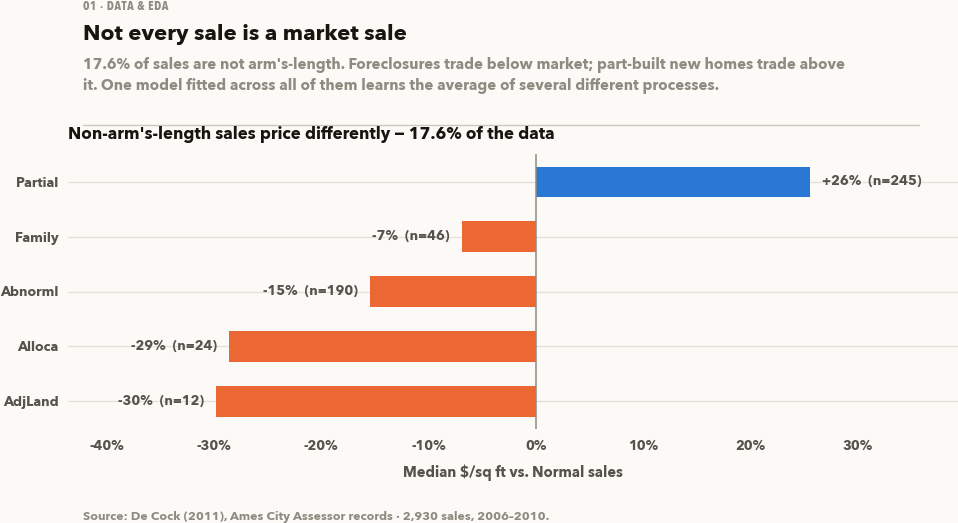

In [14]:
fig, ax = plt.subplots(figsize=(9.0, 5.3))
plot = cond.drop(index=ARMS_LENGTH_CONDITION).sort_values("discount_vs_normal")
y = np.arange(len(plot))
ax.barh(y, plot["discount_vs_normal"], height=0.55,
        color=[ORANGE if v < 0 else BLUE for v in plot["discount_vs_normal"]])
ax.set_yticks(y, plot.index)
ax.axvline(0, color=INK_MUTED, lw=1)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Median $/sq ft vs. Normal sales")
ax.set_title("Non-arm's-length sales price differently — "
             f"{1 - cond.loc[ARMS_LENGTH_CONDITION, 'share']:.1%} of the data")
for i, (v, n) in enumerate(zip(plot["discount_vs_normal"], plot["n"])):
    ax.annotate(f"{v:+.0%}  (n={n})", (v, i),
                xytext=(8 if v >= 0 else -8, 0), textcoords="offset points",
                fontsize=9, color=INK_SECONDARY, va="center",
                ha="left" if v >= 0 else "right")
ax.margins(x=0.25)
finish(fig, "Not every sale is a market sale",
       "17.6% of sales are not arm's-length. Foreclosures trade below market; part-built "
       "new homes trade above it. One model fitted across all of them learns the average "
       "of several different processes.")
save(fig, "01_sale_condition")
plt.show()

`Abnorml` (foreclosure, short sale, trade) transacts at a discount per square foot;
`Partial` at a premium, because those are new-construction homes whose assessment
predates completion. Notebook 03 fits the valuation model on `Normal` sales only and
keeps the rest for a distressed-discount analysis, which is also the input to the
loss-given-default haircut in notebook 08.

## 6. What drives price

A first look only. Notebook 03 replaces this with what each feature is worth in
dollars, which is more useful for decisions.

In [15]:
prepared = prepare(props)
target = np.log(prepared["SalePrice"])
candidates = prepared.select_dtypes("number").drop(
    columns=[c for c in ["SalePrice", "Order", "PID"] if c in prepared])
corr = candidates.corrwith(target).dropna().sort_values(key=abs, ascending=False)
corr.head(12).round(3).to_frame("correlation with log(price)")

,correlation with log(price)
Overall Qual,0.826
qual_x_sf,0.812
total_sf,0.783
Gr Liv Area,0.696
Exter Qual,0.685
Garage Cars,0.675
Kitchen Qual,0.667
total_baths,0.666
Garage Area,0.651
Bsmt Qual,0.640


Four of the top correlates (`Overall Qual`, `Exter Qual`, `Kitchen Qual`, `Bsmt Qual`)
are ordinal ladders that `ames.features` encodes as integers rather than one-hot
dummies. That choice removes roughly 40 columns from the design matrix while
strictly adding information: `Ex > Gd > TA > Fa > Po` is an ordering the model can use,
and five independent indicator columns cannot express it.

## 7. The temporal problem

The first pass split 2006–2010 sales at random (defect #7), so the model trained
on 2010 to predict 2006. For a valuation model that is backwards: in production an AVM
is always asked about the future.

  saved reports/figures/01_temporal_split.png


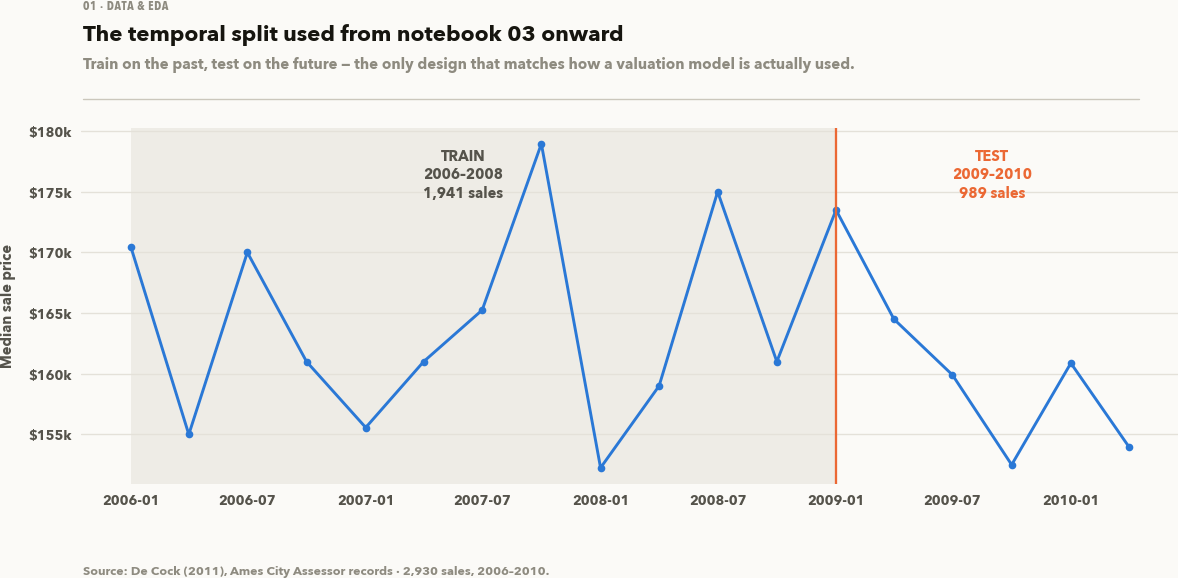

In [16]:
monthly = (props.set_index("sale_date").resample("QS")
           .agg(median_price=("SalePrice", "median"), sales=("SalePrice", "size")))
monthly = monthly[monthly["sales"] >= 20]

fig, ax = plt.subplots(figsize=(11.0, 5.8))
ax.plot(monthly.index, monthly["median_price"], color=BLUE, marker="o",
        markersize=4, label="Ames median sale price, quarterly")
split_date = pd.Timestamp("2009-01-01")
ax.axvspan(monthly.index.min(), split_date, color=GRID, alpha=0.55, lw=0)
ax.annotate("TRAIN\n2006–2008\n1,941 sales", (pd.Timestamp("2007-06-01"), ax.get_ylim()[1]),
            xytext=(0, -46), textcoords="offset points", ha="center",
            fontsize=9.5, color=INK_SECONDARY, fontweight="semibold")
ax.annotate("TEST\n2009–2010\n989 sales", (pd.Timestamp("2009-09-01"), ax.get_ylim()[1]),
            xytext=(0, -46), textcoords="offset points", ha="center",
            fontsize=9.5, color=ORANGE, fontweight="semibold")
ax.axvline(split_date, color=ORANGE, lw=1.5)
ax.yaxis.set_major_formatter(money)
ax.set_ylabel("Median sale price")
ax.set_xlabel("")
finish(fig, "The temporal split used from notebook 03 onward",
       "Train on the past, test on the future — the only design that matches how a "
       "valuation model is actually used.")
save(fig, "01_temporal_split")
plt.show()

## 8. Summary

Everything downstream reads `data/processed/properties.parquet` and the feature layer in
`ames.features`. The findings that change the modelling are:

| Finding | Consequence |
|---|---|
| Target is log-normal; raw-dollar residuals fan out | Fit on `log(SalePrice)`, retransform with Duan smearing (nb 03) |
| `NA` is a level, not a gap, in 15 columns | Ordinal ladders with `0 = absent`; nothing dropped for nullity |
| 17.6% of sales are not arm's-length | Valuation model fit on `Normal` only; the rest feed the distressed analysis |
| Quality ladders are ordered and highly correlated with price | Ordinal encoding, ~40 fewer design columns |
| Sales run 2006 → Jul 2010 across the crash | Temporal split 2006–08 / 2009–10, reported beside the random split |

In [17]:
print(f"arm's-length sales available for the AVM: "
      f"{(props['Sale Condition'] == ARMS_LENGTH_CONDITION).sum():,}")
print(f"figures written to {FIGURES.relative_to(FIGURES.parents[1])}/")

arm's-length sales available for the AVM: 2,413
figures written to reports/figures/
